## imports

In [ ]:
# load library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['figure.figsize'] = (8,4)
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from transformers import EarlyStoppingCallback
from scipy.stats import mode

## Load Dataset

In [ ]:
# load dataset
df = pd.read_csv("/content/student_people_mass_uprising_public_sentiments_dataset (2).csv", encoding="utf-8-sig")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4200, 4)


,comment,language,platform,label
0,কোন সংলাপ হবে না। পদত্যাগ চাই এবং কঠোর শাস্ত...,Bangla,Facebook,Positive
1,"সব কয়টা রাজনৈতিক করে,এরা কেউ সাধারন শিক্ষার্থী নয়",Bangla,Youtube,Negative
2,অপরাধের কোন ধর্ম দলীয় পরিচয় নেই। অপরাধী রাষ্...,Bangla,Facebook,Neutral
3,ইউনুস সরকার হিন্দুদের অত্যাচার করছে।,Bangla,Facebook,Negative
4,ছাত্ররা দেশের ভবিষ্যৎ নির্মাণের মূল কারিগর।,Bangla,Twitter (X),Positive


## Basic EDA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   comment   4200 non-null   object
 1   language  4200 non-null   object
 2   platform  4200 non-null   object
 3   label     4200 non-null   object
dtypes: object(4)
memory usage: 131.4+ KB


In [ ]:
df.describe(include="all")

,comment,language,platform,label
count,4200,4200,4200,4200
unique,4097,1,3,3
top,শিক্ষার্থীদের আন্দোলন কখনো বিফলে যায়না। তোমরা ...,Bangla,Facebook,Positive
freq,3,4200,1711,1400


In [ ]:
print("Columns:", df.columns.tolist())
print("\nLabels:", df["label"].unique())
print("\nPlatforms:", df["platform"].unique())

Columns: ['comment', 'language', 'platform', 'label']

Labels: ['Positive' 'Negative' 'Neutral']

Platforms: ['Facebook' 'Youtube' 'Twitter (X)']


Label Distribution:
label
Positive    1400
Negative    1400
Neutral     1400
Name: count, dtype: int64


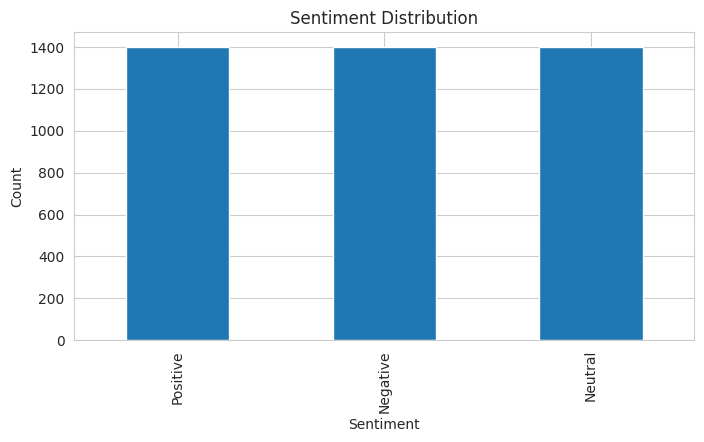

In [ ]:
print("Label Distribution:")
print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Platform Distribution:
platform
Facebook       1711
Youtube        1399
Twitter (X)    1090
Name: count, dtype: int64


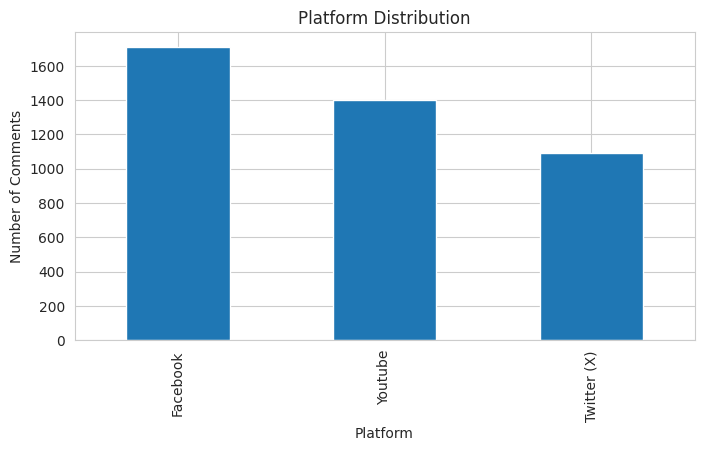

In [ ]:
print("Platform Distribution:")
print(df["platform"].value_counts())

df["platform"].value_counts().plot(kind="bar")
plt.title("Platform Distribution")
plt.xlabel("Platform")
plt.ylabel("Number of Comments")
plt.show()

## Null and Duplicate Check

In [ ]:
print("Null values:")
print(df.isnull().sum())

print("\nDuplicate comments:", df["comment"].duplicated().sum())
print("Unique comments:", df["comment"].nunique())

Null values:
comment     0
language    0
platform    0
label       0
dtype: int64

Duplicate comments: 103
Unique comments: 4097


In [ ]:
platform_sentiment = pd.crosstab(df["platform"], df["label"])
platform_sentiment

label,Negative,Neutral,Positive
platform,,,
Facebook,767,461,483
Twitter (X),407,665,18
Youtube,226,274,899


## Platform vs Sentiment

In [ ]:
platform_sentiment = pd.crosstab(df["platform"], df["label"])
platform_sentiment

label,Negative,Neutral,Positive
platform,,,
Facebook,767,461,483
Twitter (X),407,665,18
Youtube,226,274,899


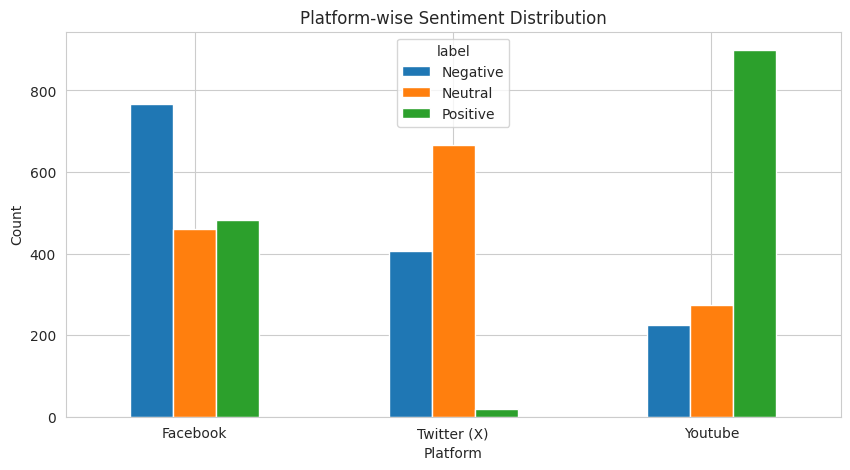

In [ ]:
platform_sentiment.plot(kind="bar", figsize=(10,5))
plt.title("Platform-wise Sentiment Distribution")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## Text Length Analysis

In [ ]:
df["char_length"] = df["comment"].astype(str).apply(len)
df["word_count"] = df["comment"].astype(str).apply(lambda x: len(x.split()))

print(df[["char_length", "word_count"]].describe())

       char_length   word_count
count  4200.000000  4200.000000
mean     68.846905    10.805714
std      36.168510     5.918102
min       8.000000     1.000000
25%      48.000000     7.000000
50%      62.000000    10.000000
75%      82.000000    13.000000
max     349.000000    57.000000


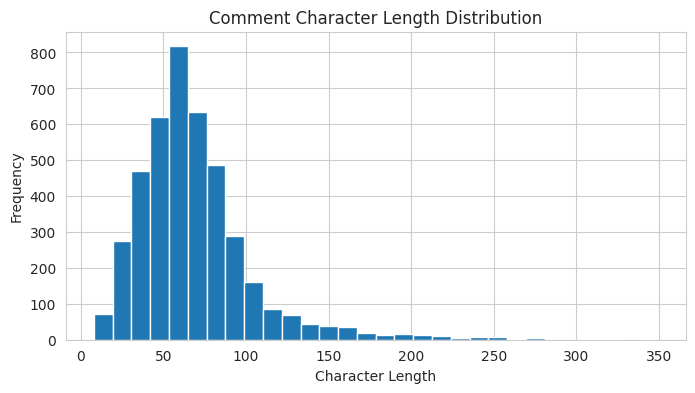

In [ ]:
plt.hist(df["char_length"], bins=30)
plt.title("Comment Character Length Distribution")
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.show()

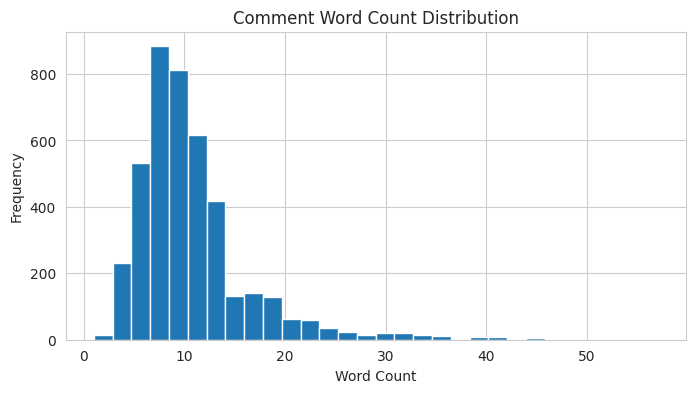

In [ ]:
plt.hist(df["word_count"], bins=30)
plt.title("Comment Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

## Remove Duplicates

In [ ]:
df = df.drop_duplicates(subset="comment").reset_index(drop=True)

print("Shape after duplicate removal:", df.shape)
print("\nLabel distribution after duplicate removal:")
print(df["label"].value_counts())

Shape after duplicate removal: (4097, 6)

Label distribution after duplicate removal:
label
Positive    1379
Negative    1376
Neutral     1342
Name: count, dtype: int64


## Bangla Stopwords

In [ ]:
BANGLA_STOPWORDS = set([
    'এবং','বা','কিন্তু','তবে','অথবা','তাছাড়া','এছাড়া','তবুও','বরং','সুতরাং','অতএব',
    'এই','ওই','সেই','এটা','ওটা','সেটা','এটি','ওটি','সেটি','উক্ত',
    'আমি','আমরা','তুমি','তোমরা','সে','তারা','আপনি','আপনারা',
    'এখানে','সেখানে','ওখানে','এখন','তখন','আজ','কাল',
    'হয়','হবে','হলো','হয়েছে','হচ্ছে','ছিল','ছিলো',
    'আছে','আছি','থাকে',
    'করা','করে','করেছে','করছে','করবে','করতে','করলে',
    'হলে','গেছে','যাচ্ছে','আসছে','এসেছে','আসবে','যাবে',
    'দিল','নিল','পেল',
    'একটি','একটা','কোনো','কোন','সব','সকল','প্রতি',
    'এর','তার','যার','কার',
    'থেকে','পর্যন্ত','দিয়ে','নিয়ে',
    'জন্য','জন্যে','সাথে','সহ','ছাড়া','দ্বারা',
    'মধ্যে','ভিতরে','বাইরে','উপর','নিচে','পরে','আগে','দিকে','পাশে',
    'কি','কী','কেন','কীভাবে',
    'যেন','যেমন','তেমন','ইত্যাদি','প্রভৃতি',
    'ইহা','উহা','তাহা','ইহার','উহার','তাহার',
    'ইহাতে','তাহাতে','উহাতে','ইহাকে','তাহাকে','উহাকে',
    'বিষয়ে','ব্যাপারে','সংক্রান্ত','সম্পর্কিত','অনুযায়ী','মাধ্যমে','উদ্দেশ্যে'
])



print("Total stopwords:", len(BANGLA_STOPWORDS))

Total stopwords: 121


## Baseline ML preprocessing

In [ ]:
def preprocess_baseline(text):
    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize("NFC", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove English characters
    text = re.sub(r"[a-zA-Z]", "", text)

    # Remove numbers: English + Bangla
    text = re.sub(r"[0-9০-৯]", "", text)

    # Keep only Bangla Unicode block and spaces
    text = re.sub(r"[^\u0980-\u09FF\s]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Stopword removal + short token removal
    tokens = text.split()
    tokens = [t for t in tokens if t not in BANGLA_STOPWORDS]
    tokens = [t for t in tokens if len(t) > 1]

    return " ".join(tokens)

## BERT preprocessing

In [ ]:
def preprocess_bert(text):
    text = str(text)

    # Unicode normalization
    text = unicodedata.normalize("NFC", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

## Apply Preprocesing

In [ ]:
df["clean_text_baseline"] = df["comment"].apply(preprocess_baseline)
df["clean_text_bert"] = df["comment"].apply(preprocess_bert)

empty_baseline = (df["clean_text_baseline"].str.strip() == "").sum()
empty_bert = (df["clean_text_bert"].str.strip() == "").sum()

print("Empty baseline comments:", empty_baseline)
print("Empty BERT comments:", empty_bert)

Empty baseline comments: 0
Empty BERT comments: 0


In [ ]:
df = df[df["clean_text_baseline"].str.strip() != ""].reset_index(drop=True)

print("Final shape after cleaning:", df.shape)
print(df["label"].value_counts())

Final shape after cleaning: (4097, 8)
label
Positive    1379
Negative    1376
Neutral     1342
Name: count, dtype: int64


In [ ]:
for label in ["Positive", "Negative", "Neutral"]:
    sample = df[df["label"] == label].iloc[0]
    print("\nLabel:", label)
    print("Original:", sample["comment"])
    print("Baseline Cleaned:", sample["clean_text_baseline"])
    print("BERT Cleaned:", sample["clean_text_bert"])


Label: Positive
Original: কোন সংলাপ হবে না। পদত্যাগ চাই এবং কঠোর শাস্তি চাই
Baseline Cleaned: সংলাপ না পদত্যাগ চাই কঠোর শাস্তি চাই
BERT Cleaned: কোন সংলাপ হবে না। পদত্যাগ চাই এবং কঠোর শাস্তি চাই

Label: Negative
Original: সব কয়টা রাজনৈতিক করে,এরা কেউ সাধারন শিক্ষার্থী নয়
Baseline Cleaned: কয়টা রাজনৈতিক এরা কেউ সাধারন শিক্ষার্থী নয়
BERT Cleaned: সব কয়টা রাজনৈতিক করে,এরা কেউ সাধারন শিক্ষার্থী নয়

Label: Neutral
Original: অপরাধের কোন ধর্ম দলীয় পরিচয় নেই। অপরাধী রাষ্ট্রীয় আইনের কাঠামোয় বিচার হবে এর জন্য দল দায়ভার নেবে না।
Baseline Cleaned: অপরাধের ধর্ম দলীয় পরিচয় নেই অপরাধী রাষ্ট্রীয় আইনের কাঠামোয় বিচার দল দায়ভার নেবে না
BERT Cleaned: অপরাধের কোন ধর্ম দলীয় পরিচয় নেই। অপরাধী রাষ্ট্রীয় আইনের কাঠামোয় বিচার হবে এর জন্য দল দায়ভার নেবে না।


In [ ]:
df = df.drop_duplicates(subset="clean_text_baseline").reset_index(drop=True)

print("Shape after removing cleaned-text duplicates:", df.shape)
print(df["label"].value_counts())

Shape after removing cleaned-text duplicates: (4083, 8)
label
Positive    1375
Negative    1367
Neutral     1341
Name: count, dtype: int64


## Data Split

In [ ]:
X = df["clean_text_baseline"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

print("Leakage count:", len(set(X_train).intersection(set(X_test))))

Train size: (3266,)
Test size: (817,)

Train label distribution:
label
Positive    1100
Negative    1093
Neutral     1073
Name: count, dtype: int64

Test label distribution:
label
Positive    275
Negative    274
Neutral     268
Name: count, dtype: int64
Leakage count: 0


## **TF**-IDF initialize

In [ ]:
tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(2, 5),
    max_features=10000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("X_train TF-IDF shape:", X_train_tfidf.shape)
print("X_test TF-IDF shape:", X_test_tfidf.shape)

X_train TF-IDF shape: (3266, 10000)
X_test TF-IDF shape: (817, 10000)


## Helper

In [ ]:
results = []

def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro")
    recall = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")

    results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1
    })

    print("="*60)
    print(model_name)
    print("="*60)
    print("Accuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=["Negative", "Neutral", "Positive"])

    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Neutral", "Positive"],
        yticklabels=["Negative", "Neutral", "Positive"]
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return y_pred

## Logistic Regression

Logistic Regression
Accuracy: 0.8433292533659731

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.75      0.81       274
     Neutral       0.93      0.89      0.91       268
    Positive       0.75      0.89      0.81       275

    accuracy                           0.84       817
   macro avg       0.85      0.84      0.84       817
weighted avg       0.85      0.84      0.84       817



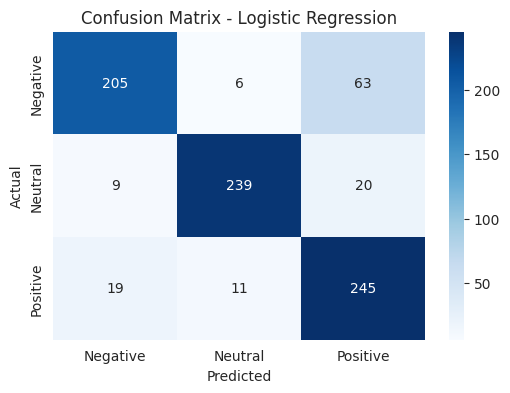

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

y_pred_lr = evaluate_model(
    "Logistic Regression",
    lr_model,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

## Naive Bayes

Naive Bayes
Accuracy: 0.8115055079559363

Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.70      0.77       274
     Neutral       0.88      0.90      0.89       268
    Positive       0.72      0.83      0.77       275

    accuracy                           0.81       817
   macro avg       0.82      0.81      0.81       817
weighted avg       0.82      0.81      0.81       817



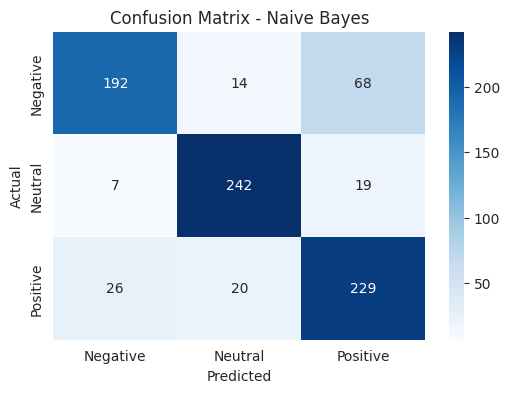

In [ ]:
nb_model = MultinomialNB()

y_pred_nb = evaluate_model(
    "Naive Bayes",
    nb_model,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

## Random Forest

Random Forest
Accuracy: 0.824969400244798

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.75      0.81       274
     Neutral       0.89      0.87      0.88       268
    Positive       0.73      0.85      0.79       275

    accuracy                           0.82       817
   macro avg       0.83      0.83      0.83       817
weighted avg       0.83      0.82      0.83       817



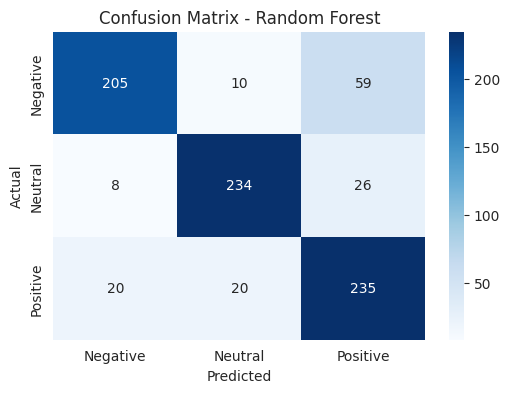

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

y_pred_rf = evaluate_model(
    "Random Forest",
    rf_model,
    X_train_tfidf,
    X_test_tfidf,
    y_train,
    y_test
)

## Baseline Result Table

In [ ]:
baseline_results = pd.DataFrame(results)
baseline_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.843329,0.853458,0.843625,0.844499
1,Naive Bayes,0.811506,0.818276,0.812147,0.811401
2,Random Forest,0.824969,0.833522,0.825285,0.826098


In [ ]:
baseline_results.sort_values(by="Macro F1", ascending=False)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.843329,0.853458,0.843625,0.844499
2,Random Forest,0.824969,0.833522,0.825285,0.826098
1,Naive Bayes,0.811506,0.818276,0.812147,0.811401


## Baseline visualization

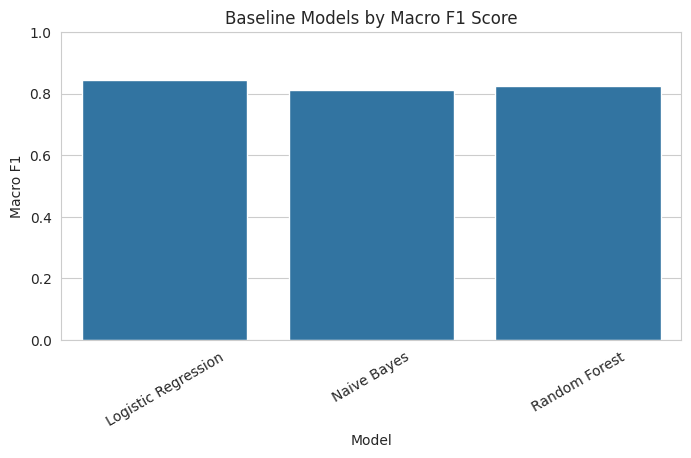

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=baseline_results,
    x="Model",
    y="Macro F1"
)

plt.title("Baseline Models by Macro F1 Score")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

## BERT setup

In [ ]:
!pip install transformers datasets accelerate -q

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
Tesla T4


## Bert data

In [ ]:
bert_df = df[["clean_text_bert", "label"]].copy()
bert_df = bert_df.rename(columns={"clean_text_bert": "text"})

label_encoder = LabelEncoder()
bert_df["label_id"] = label_encoder.fit_transform(bert_df["label"])

print(label_encoder.classes_)
bert_df.head()

['Negative' 'Neutral' 'Positive']


,text,label,label_id
0,কোন সংলাপ হবে না। পদত্যাগ চাই এবং কঠোর শাস্তি চাই,Positive,2
1,"সব কয়টা রাজনৈতিক করে,এরা কেউ সাধারন শিক্ষার্থ...",Negative,0
2,অপরাধের কোন ধর্ম দলীয় পরিচয় নেই। অপরাধী রাষ্...,Neutral,1
3,ইউনুস সরকার হিন্দুদের অত্যাচার করছে।,Negative,0
4,ছাত্ররা দেশের ভবিষ্যৎ নির্মাণের মূল কারিগর।,Positive,2


## Data Split

In [ ]:
train_df, temp_df = train_test_split(
    bert_df,
    test_size=0.2,
    random_state=42,
    stratify=bert_df["label_id"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label_id"]
)

print(train_df.shape, val_df.shape, test_df.shape)
print(train_df["label"].value_counts())
print()
print(val_df["label"].value_counts())
print()
print(test_df["label"].value_counts())

(3266, 3) (408, 3) (409, 3)
label
Positive    1100
Negative    1093
Neutral     1073
Name: count, dtype: int64

label
Positive    137
Negative    137
Neutral     134
Name: count, dtype: int64

label
Positive    138
Negative    137
Neutral     134
Name: count, dtype: int64


## BanglaBert

In [ ]:
#initialize
MODEL_NAME = "sagorsarker/bangla-bert-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = Dataset.from_pandas(train_df[["text", "label_id"]])
val_dataset = Dataset.from_pandas(val_df[["text", "label_id"]])
test_dataset = Dataset.from_pandas(test_df[["text", "label_id"]])

train_dataset = train_dataset.rename_column("label_id", "labels")
val_dataset = val_dataset.rename_column("label_id", "labels")
test_dataset = test_dataset.rename_column("label_id", "labels")

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/3266 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/409 [00:00<?, ? examples/s]

In [ ]:
#compute metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_precision": precision_score(labels, preds, average="macro"),
        "macro_recall": recall_score(labels, preds, average="macro"),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

In [ ]:
#train model
banglabert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

training_args = TrainingArguments(
    output_dir="./banglabert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_dir="./banglabert_logs",
    logging_steps=50,
    report_to="none"
)

trainer = Trainer(
    model=banglabert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecate

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.419687,0.387533,0.857843,0.874458,0.857737,0.859700
2,0.280785,0.511792,0.855392,0.865849,0.855522,0.856593
3,0.166102,0.700550,0.855392,0.865778,0.855413,0.857010


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1227, training_loss=0.3444269552596138, metrics={'train_runtime': 340.7809, 'train_samples_per_second': 95.839, 'train_steps_per_second': 12.002, 'total_flos': 644496316724736.0, 'train_loss': 0.3444269552596138, 'epoch': 3.0})

In [ ]:
#evaluate model
banglabert_test_results = trainer.evaluate(test_dataset)
banglabert_test_results

{'eval_loss': 0.35046684741973877,
 'eval_accuracy': 0.8704156479217604,
 'eval_macro_precision': 0.8812805572407886,
 'eval_macro_recall': 0.8705496636146465,
 'eval_macro_f1': 0.8725902814903918,
 'eval_runtime': 3.1056,
 'eval_samples_per_second': 131.696,
 'eval_steps_per_second': 16.744,
 'epoch': 3.0}

In [ ]:
#report
predictions = trainer.predict(test_dataset)
banglabert_preds = np.argmax(predictions.predictions, axis=1)
banglabert_true = predictions.label_ids

print(classification_report(
    banglabert_true,
    banglabert_preds,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.88      0.80      0.84       137
     Neutral       0.99      0.90      0.95       134
    Positive       0.77      0.91      0.84       138

    accuracy                           0.87       409
   macro avg       0.88      0.87      0.87       409
weighted avg       0.88      0.87      0.87       409



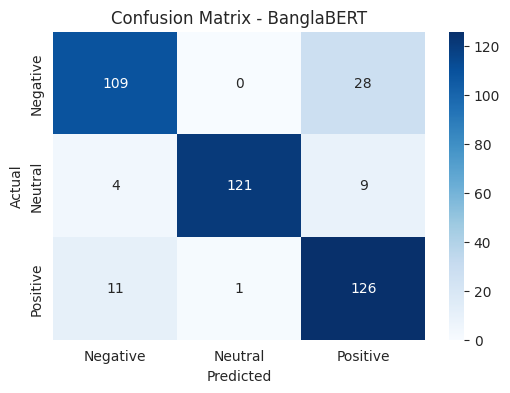

In [ ]:
#confusion matrix
cm = confusion_matrix(banglabert_true, banglabert_preds)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - BanglaBERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#result
banglabert_result_row = {
    "Model": "BanglaBERT Fine-tuned",
    "Accuracy": banglabert_test_results["eval_accuracy"],
    "Macro Precision": banglabert_test_results["eval_macro_precision"],
    "Macro Recall": banglabert_test_results["eval_macro_recall"],
    "Macro F1": banglabert_test_results["eval_macro_f1"]
}

banglabert_result_row

{'Model': 'BanglaBERT Fine-tuned',
 'Accuracy': 0.8704156479217604,
 'Macro Precision': 0.8812805572407886,
 'Macro Recall': 0.8705496636146465,
 'Macro F1': 0.8725902814903918}

## XLM-Roberta

In [ ]:
#intialize model
XLMR_MODEL_NAME = "xlm-roberta-base"

xlmr_tokenizer = AutoTokenizer.from_pretrained(XLMR_MODEL_NAME)

def xlmr_tokenize_function(batch):
    return xlmr_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

In [ ]:
#dataset
xlmr_train_dataset = Dataset.from_pandas(train_df[["text", "label_id"]])
xlmr_val_dataset = Dataset.from_pandas(val_df[["text", "label_id"]])
xlmr_test_dataset = Dataset.from_pandas(test_df[["text", "label_id"]])

xlmr_train_dataset = xlmr_train_dataset.rename_column("label_id", "labels")
xlmr_val_dataset = xlmr_val_dataset.rename_column("label_id", "labels")
xlmr_test_dataset = xlmr_test_dataset.rename_column("label_id", "labels")

xlmr_train_dataset = xlmr_train_dataset.map(xlmr_tokenize_function, batched=True)
xlmr_val_dataset = xlmr_val_dataset.map(xlmr_tokenize_function, batched=True)
xlmr_test_dataset = xlmr_test_dataset.map(xlmr_tokenize_function, batched=True)

xlmr_train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
xlmr_val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
xlmr_test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/3266 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/409 [00:00<?, ? examples/s]

In [ ]:
xlmr_model = AutoModelForSequenceClassification.from_pretrained(XLMR_MODEL_NAME,num_labels=3)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
xlmr_training_args = TrainingArguments(
    output_dir="./xlmr_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_dir="./xlmr_logs",
    logging_steps=50,
    report_to="none"
)

xlmr_trainer = Trainer(
    model=xlmr_model,
    args=xlmr_training_args,
    train_dataset=xlmr_train_dataset,
    eval_dataset=xlmr_val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

xlmr_trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.587387,0.462222,0.838235,0.851455,0.838381,0.840308
2,0.483625,0.454452,0.857843,0.861494,0.858227,0.859204
3,0.417734,0.479637,0.850490,0.859185,0.850764,0.852050
4,0.389098,0.495544,0.850490,0.854832,0.851091,0.850715


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1636, training_loss=0.5212997457508936, metrics={'train_runtime': 980.1823, 'train_samples_per_second': 33.32, 'train_steps_per_second': 4.173, 'total_flos': 859328422299648.0, 'train_loss': 0.5212997457508936, 'epoch': 4.0})

In [ ]:
xlmr_test_results = xlmr_trainer.evaluate(xlmr_test_dataset)
xlmr_test_results

{'eval_loss': 0.46956226229667664,
 'eval_accuracy': 0.8459657701711492,
 'eval_macro_precision': 0.8478883381460026,
 'eval_macro_recall': 0.8466290150853687,
 'eval_macro_f1': 0.8466606397512738,
 'eval_runtime': 2.9559,
 'eval_samples_per_second': 138.368,
 'eval_steps_per_second': 17.592,
 'epoch': 4.0}

In [ ]:
xlmr_predictions = xlmr_trainer.predict(xlmr_test_dataset)

xlmr_preds = np.argmax(xlmr_predictions.predictions, axis=1)
xlmr_true = xlmr_predictions.label_ids

print(classification_report(
    xlmr_true,
    xlmr_preds,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.87      0.80      0.83       137
     Neutral       0.91      0.93      0.92       134
    Positive       0.77      0.81      0.79       138

    accuracy                           0.85       409
   macro avg       0.85      0.85      0.85       409
weighted avg       0.85      0.85      0.85       409



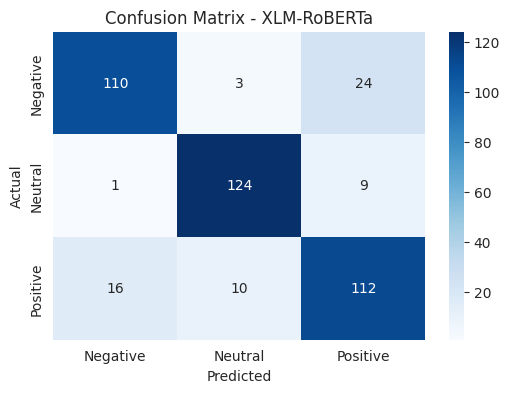

In [ ]:
xlmr_cm = confusion_matrix(xlmr_true, xlmr_preds)

plt.figure(figsize=(6,4))
sns.heatmap(
    xlmr_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - XLM-RoBERTa")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
xlmr_result_row = {
    "Model": "XLM-RoBERTa Fine-tuned",
    "Accuracy": xlmr_test_results["eval_accuracy"],
    "Macro Precision": xlmr_test_results["eval_macro_precision"],
    "Macro Recall": xlmr_test_results["eval_macro_recall"],
    "Macro F1": xlmr_test_results["eval_macro_f1"]
}

xlmr_result_row

{'Model': 'XLM-RoBERTa Fine-tuned',
 'Accuracy': 0.8459657701711492,
 'Macro Precision': 0.8478883381460026,
 'Macro Recall': 0.8466290150853687,
 'Macro F1': 0.8466606397512738}

## mBERT

In [ ]:
MBERT_MODEL_NAME = "bert-base-multilingual-cased"

In [ ]:
mbert_tokenizer = AutoTokenizer.from_pretrained(MBERT_MODEL_NAME)

def mbert_tokenize_function(batch):
    return mbert_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
mbert_train_dataset = Dataset.from_pandas(train_df[["text", "label_id"]])
mbert_val_dataset = Dataset.from_pandas(val_df[["text", "label_id"]])
mbert_test_dataset = Dataset.from_pandas(test_df[["text", "label_id"]])

mbert_train_dataset = mbert_train_dataset.rename_column("label_id", "labels")
mbert_val_dataset = mbert_val_dataset.rename_column("label_id", "labels")
mbert_test_dataset = mbert_test_dataset.rename_column("label_id", "labels")

mbert_train_dataset = mbert_train_dataset.map(mbert_tokenize_function, batched=True)
mbert_val_dataset = mbert_val_dataset.map(mbert_tokenize_function, batched=True)
mbert_test_dataset = mbert_test_dataset.map(mbert_tokenize_function, batched=True)

mbert_train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
mbert_val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
mbert_test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/3266 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/409 [00:00<?, ? examples/s]

In [ ]:
mbert_model = AutoModelForSequenceClassification.from_pretrained(
    MBERT_MODEL_NAME,
    num_labels=3
)

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
mbert_training_args = TrainingArguments(
    output_dir="./mbert_results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_dir="./mbert_logs",
    logging_steps=50,
    report_to="none"
)

mbert_trainer = Trainer(
    model=mbert_model,
    args=mbert_training_args,
    train_dataset=mbert_train_dataset,
    eval_dataset=mbert_val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

mbert_trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.543423,0.480682,0.823529,0.849659,0.823783,0.824823
2,0.432098,0.513440,0.821078,0.858085,0.821567,0.819760
3,0.372005,0.451738,0.855392,0.858496,0.855685,0.856284
4,0.428937,0.622502,0.845588,0.849960,0.846116,0.845328
5,0.321411,0.633803,0.855392,0.862637,0.855413,0.856825
6,0.215689,0.826296,0.852941,0.852792,0.853361,0.852931
7,0.054344,0.972798,0.843137,0.843330,0.843465,0.843390


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=2863, training_loss=0.35036503648241624, metrics={'train_runtime': 1387.0431, 'train_samples_per_second': 23.546, 'train_steps_per_second': 2.949, 'total_flos': 1503824739024384.0, 'train_loss': 0.35036503648241624, 'epoch': 7.0})

In [ ]:
mbert_test_results = mbert_trainer.evaluate(mbert_test_dataset)
mbert_test_results

{'eval_loss': 0.6704533696174622,
 'eval_accuracy': 0.8484107579462102,
 'eval_macro_precision': 0.855106760062335,
 'eval_macro_recall': 0.8487929020927311,
 'eval_macro_f1': 0.8499684898606731,
 'eval_runtime': 3.1989,
 'eval_samples_per_second': 127.855,
 'eval_steps_per_second': 16.255,
 'epoch': 7.0}

In [ ]:
mbert_predictions = mbert_trainer.predict(mbert_test_dataset)

mbert_preds = np.argmax(mbert_predictions.predictions, axis=1)
mbert_true = mbert_predictions.label_ids

print(classification_report(
    mbert_true,
    mbert_preds,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    Negative       0.89      0.79      0.83       137
     Neutral       0.92      0.90      0.91       134
    Positive       0.76      0.86      0.80       138

    accuracy                           0.85       409
   macro avg       0.86      0.85      0.85       409
weighted avg       0.85      0.85      0.85       409



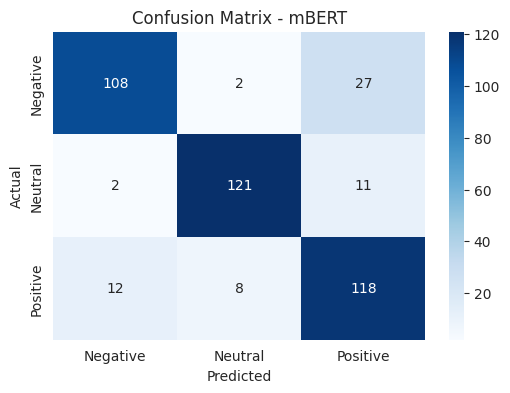

In [ ]:
mbert_cm = confusion_matrix(mbert_true, mbert_preds)

plt.figure(figsize=(6,4))
sns.heatmap(
    mbert_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - mBERT")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
mbert_result_row = {
    "Model": "mBERT Fine-tuned",
    "Accuracy": mbert_test_results["eval_accuracy"],
    "Macro Precision": mbert_test_results["eval_macro_precision"],
    "Macro Recall": mbert_test_results["eval_macro_recall"],
    "Macro F1": mbert_test_results["eval_macro_f1"]
}

mbert_result_row

{'Model': 'mBERT Fine-tuned',
 'Accuracy': 0.8484107579462102,
 'Macro Precision': 0.855106760062335,
 'Macro Recall': 0.8487929020927311,
 'Macro F1': 0.8499684898606731}

In [ ]:
final_results = pd.concat([
    final_results,
    pd.DataFrame([mbert_result_row])
], ignore_index=True)

final_results = final_results.sort_values(by="Macro F1", ascending=False)
final_results

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,BanglaBERT Fine-tuned,0.870416,0.881281,0.870550,0.872590
5,mBERT Fine-tuned,0.848411,0.855107,0.848793,0.849968
1,XLM-RoBERTa Fine-tuned,0.845966,0.847888,0.846629,0.846661
2,Logistic Regression,0.843329,0.853458,0.843625,0.844499
3,Random Forest,0.824969,0.833522,0.825285,0.826098
4,Naive Bayes,0.811506,0.818276,0.812147,0.811401


## Final Plot

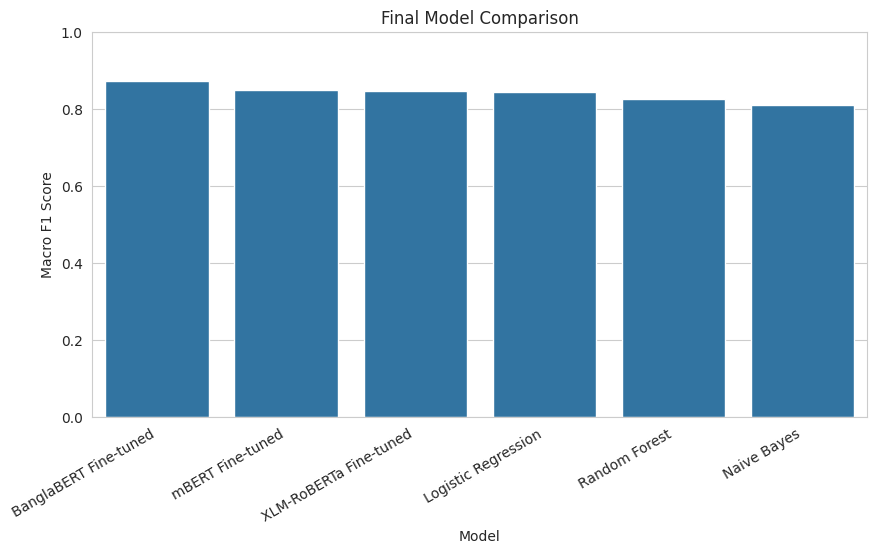

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=final_results,
    x="Model",
    y="Macro F1"
)

plt.title("Final Model Comparison")
plt.ylabel("Macro F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.show()

In [ ]:
final_results.to_csv("final_results.csv", index=False)